# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

When people say a model is “linear,” they're talking about the coefficients, not the inputs. So even if you do something like square a variable, it's still linear as long as you're just multiplying by coefficients and adding things together. In other words, nothing weird is happening to the betas themselves.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

For dummy variables, the coefficient is basically telling you how that group compares to the baseline group. Since one category gets left out, the intercept kind of represents that baseline, and everything else is measured relative to it. So you can think of it as “how much higher or lower is this category compared to the reference one.”

3. Can linear regression be used for classification? Explain why, or why not.

You can use linear regression for classification if you really want to, but it's not great. The main issue is it can give predictions below 0 or above 1, which doesn't make sense if you're treating them like probabilities. That's why logistic regression is usually used instead since it naturally keeps things between 0 and 1.

4. What are signs that your linear model is over-fitting?

If your model looks amazing on training data but then falls apart on test data, that's a pretty clear red flag. It means it's probably memorizing instead of actually learning anything useful. Also, if the coefficients are super large or seem to jump around a lot, that's usually another sign something's off.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity is when your predictors are kind of telling you the same thing. If you think about it in a two-stage sense, if one variable can basically be predicted using the others, then it's not bringing much new information. That's when the model starts struggling to figure out which variable is actually responsible for changes in the outcome, and the coefficients get unstable.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

Even though it's called a linear model, you can still handle nonlinear patterns by transforming the inputs. Like adding x^2, x^3, or interaction terms between variables. The relationship becomes nonlinear in terms of the inputs, but since the coefficients are still just added and multiplied, the model itself stays “linear.”

7. What is the interpretation of the slope coefficient in a linear regression?

The slope tells you how much you expect y to change when x goes up by one unit, assuming everything else is held constant. It's basically the “per unit change” effect.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split is just one cut of the data, so it's quick but kind of dependent on how the data got split. k-fold cross validation, on the other hand, rotates through multiple splits and averages the results, so it's more reliable, just a bit more work computationally.

9. How is the $k$ in $k$-fold cross validation typically selected?

Most of the time people just go with 5 or 10. It's not super deep, it's more of a practical choice. Smaller k is faster, larger k is a bit more stable, and 5 or 10 ends up being a good middle ground.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [6]:
! git clone https://github.com/Humzah-Syed/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 30 (delta 8), reused 4 (delta 4), pack-reused 18 (from 1)
Receiving objects: 100% (30/30), 31.69 KiB | 2.64 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Download complete
Extracting data files...
Data extracted


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('./data/airbnb_hw.csv', encoding="utf-8")

In [8]:

df.head()
df.shape
df.columns

Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object')

In [9]:
df.columns = df.columns.str.strip()

df["Price"] = pd.to_numeric(
    df["Price"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["Review Scores Rating"] = pd.to_numeric(
    df["Review Scores Rating"],
    errors="coerce"
)

In [10]:
group_means = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()
group_means

,Price,Review Scores Rating
Neighbourhood,,
Bronx,94.660870,91.654378
Brooklyn,129.500471,92.363497
Manhattan,198.474584,91.801785
Queens,103.222125,91.549057
Staten Island,163.462585,90.843750


In [11]:
group_means["Price"].sort_values(ascending=False)

,Price
Neighbourhood,
Manhattan,198.474584
Staten Island,163.462585
Brooklyn,129.500471
Queens,103.222125
Bronx,94.660870


In [12]:
import numpy as np

df["log_price"] = np.log(df["Price"])

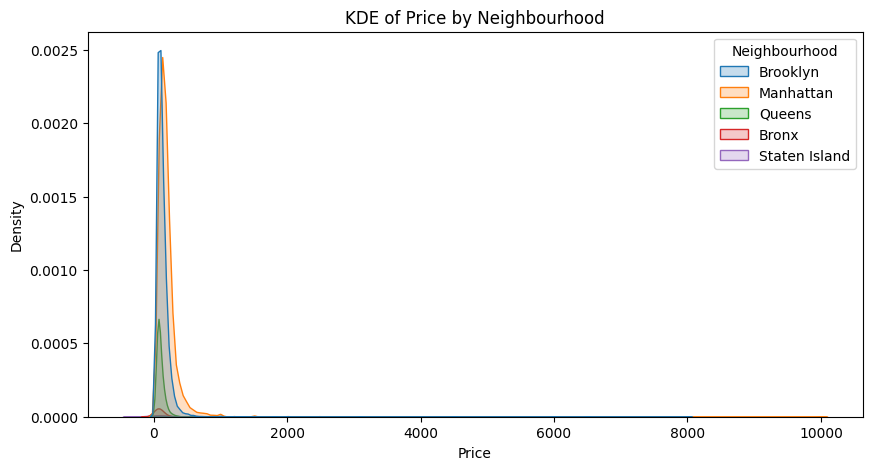

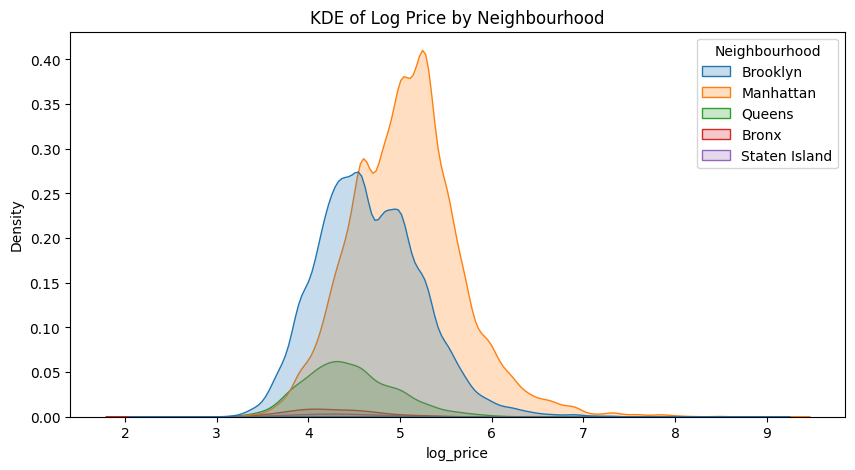

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x="Price", hue="Neighbourhood", fill=True)
plt.title("KDE of Price by Neighbourhood")
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood", fill=True)
plt.title("KDE of Log Price by Neighbourhood")
plt.show()

I computed the average price and average review score by borough using a groupby operation. The borough with the highest average price is the most expensive on average.

The kernel density plot of price shows a right-skewed distribution, especially for higher-priced listings. After taking the log of price, the distributions become more symmetric and easier to compare across neighborhoods. The log transformation reduces the influence of extreme high prices and makes the differences between boroughs more visible.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/cars_hw.csv", encoding="utf-8")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [15]:
df["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


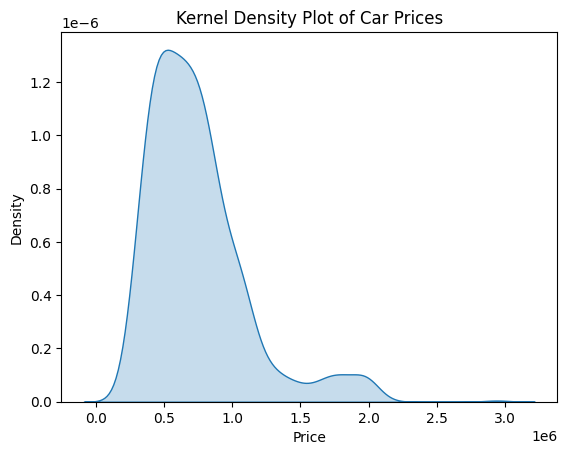

In [16]:
sns.kdeplot(df["Price"], fill=True)
plt.title("Kernel Density Plot of Car Prices")
plt.show()

In [17]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


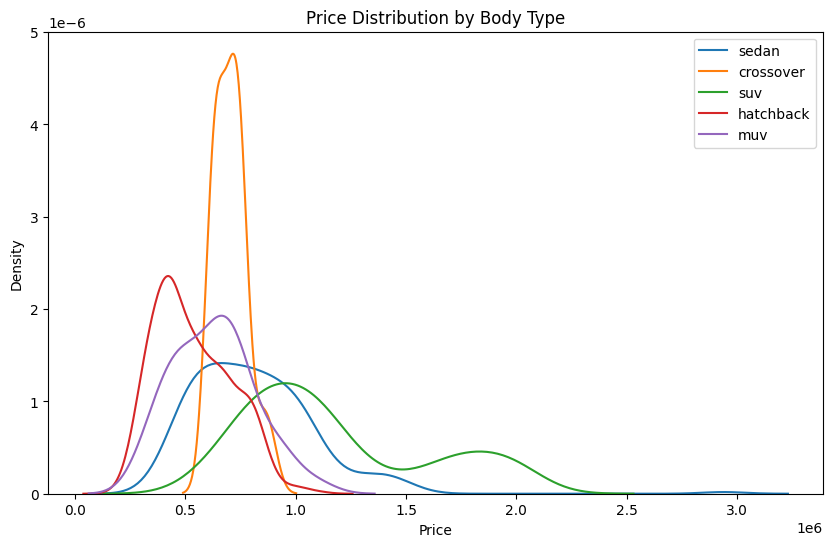

In [18]:
plt.figure(figsize=(10,6))

for body in df["Body_Type"].unique():
    subset = df[df["Body_Type"] == body]
    sns.kdeplot(subset["Price"], label=body)

plt.legend()
plt.title("Price Distribution by Body Type")
plt.show()

The overall price distribution is definitely right skewed. Most cars sit somewhere between about 400,000 and 1,000,000 rupees, and then there's this long stretch off to the right where a smaller number of cars jump well past 2,000,000. Those higher-end models are clearly stretching the distribution out.

Looking at the grouped density plot, SUVs stand out pretty quickly. Their curve is shifted further to the right than the others, which tells me they're generally more expensive. They also cover a wider price range. Sedans do have some very expensive outliers, but most of their mass is still a bit lower than SUVs.

In terms of variability, SUVs again seem to have the most going on. Their distribution spreads out the most across prices, so the variance looks highest there. Hatchbacks, on the other hand, are much more concentrated in the lower price range. Their curve is tighter and doesn't stretch very far, so they likely have the smallest variance.

In [19]:
import statsmodels.api as sm

X = df["Seating_Capacity"]
X = sm.add_constant(X)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0245
Time:                        01:35:47   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [20]:
df["Seating_Capacity"] = df["Seating_Capacity"].astype("category")

model_cat = sm.OLS.from_formula("Price ~ C(Seating_Capacity)", data=df).fit()
print(model_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000267
Time:                        01:35:47   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [21]:
import numpy as np

current_year = 2024  # or whatever is appropriate
df["Age"] = current_year - df["Make_Year"]

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

degrees = range(1, 6)
cv_scores = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    score = cross_val_score(model, df[["Age"]], df["Price"],
                            cv=10,
                            scoring="neg_mean_squared_error")
    cv_scores.append(-score.mean())

cv_scores

[np.float64(100295370079.45541),
 np.float64(100814620596.42154),
 np.float64(100380163091.91904),
 np.float64(100474431121.09125),
 np.float64(100131346196.67825)]

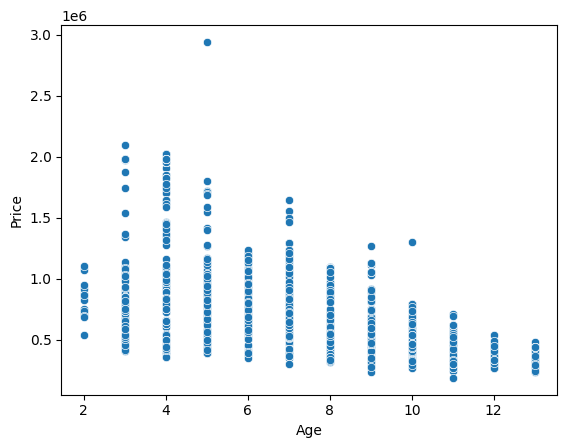

In [23]:
sns.scatterplot(x="Age", y="Price", data=df)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


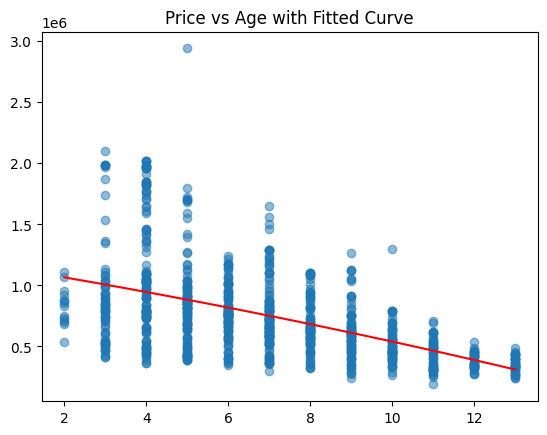

In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

best_degree = 2  # replace with your CV result

model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
model.fit(df[["Age"]], df["Price"])

age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 100)
price_pred = model.predict(age_grid.reshape(-1,1))

plt.scatter(df["Age"], df["Price"], alpha=0.5)
plt.plot(age_grid, price_pred, color="red")
plt.title("Price vs Age with Fitted Curve")
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [28]:
import pandas as pd

df = pd.read_csv("./heart_hw.csv", encoding="utf-8")
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [29]:
df.groupby("transplant")["y"].mean()

,y
transplant,
control,0.117647
treatment,0.347826


In [30]:
ate = df[df["transplant"]=="treatment"]["y"].mean() - \
      df[df["transplant"]=="control"]["y"].mean()

ate

np.float64(0.23017902813299232)

The ATE represents the increase in three-year survival probability from receiving a transplant. The difference is 0.23, that means transplant recipients are 23 percentage points more likely to survive three years.

In [31]:
import statsmodels.formula.api as smf

model1 = smf.ols("y ~ C(transplant)", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0133
Time:                        01:49:15   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [32]:
model2 = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000357
Time:                        01:49:34   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

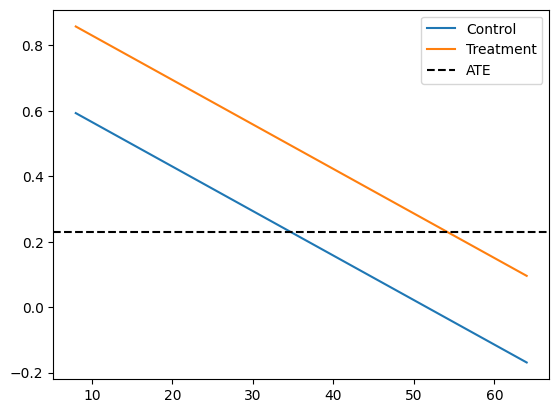

In [33]:
import numpy as np
import matplotlib.pyplot as plt

ages = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model2.predict(pd.DataFrame({
    "age": ages,
    "transplant": "control"
}))

pred_treat = model2.predict(pd.DataFrame({
    "age": ages,
    "transplant": "treatment"
}))

plt.plot(ages, pred_control, label="Control")
plt.plot(ages, pred_treat, label="Treatment")
plt.axhline(y=ate, linestyle="--", color="black", label="ATE")
plt.legend()
plt.show()

In [34]:
model3 = smf.ols("y ~ C(transplant) * age", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000310
Time:                        01:49:52   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [36]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

def cross_validate_model(formula):
    kf = KFold(n_splits=10, shuffle=True, random_state=1)
    mse_list = []

    for train_index, test_index in kf.split(df):
        train = df.iloc[train_index]
        test = df.iloc[test_index]

        model = smf.ols(formula, data=train).fit()
        preds = model.predict(test)
        mse = mean_squared_error(test["y"], preds)
        mse_list.append(mse)

    return np.mean(mse_list)

mse1 = cross_validate_model("y ~ C(transplant)")
mse2 = cross_validate_model("y ~ C(transplant) + age")
mse3 = cross_validate_model("y ~ C(transplant) * age")

print("Model 1 MSE:", mse1)
print("Model 2 MSE:", mse2)
print("Model 3 MSE:", mse3)

Model 1 MSE: 0.19497249586192153
Model 2 MSE: 0.17926415954952163
Model 3 MSE: 0.17880206762517423


If this model were used to prioritize transplant access, there would be serious concerns.

First, this is a linear probability model, which can predict probabilities outside the 0-1 range. That alone makes it questionable for clinical decision making.

Second, the interaction suggests that transplant benefits decline with age. Using such a model could systematically deprioritize older patients, raising ethical concerns about fairness and discrimination.

Third, the model only includes age and transplant status. It omits other medical and socioeconomic variables that may affect survival. If transplant recipients were healthier to begin with, the model could overstate the true causal effect.